# Cyclic Single-Door Criterion — E. coli Network Analysis

**Purpose:** Assess the identifiability of every directed edge in the *E. coli* transcriptional
regulatory network using the sigma-separation single-door criterion (Forre & Mooij 2018;
Rantanen et al. 2020), diagnose *why* edges are unidentifiable, and quantify how targeted
genetic interventions (`do(v)`) could rescue identifiability.

## Methods summary

- **sigma-single-door:** For each edge `cause -> effect`, we test whether a valid
  back-door adjustment set exists in the sigma-extension graph (Perkovic et al. 2018 O-set,
  which is *complete*: no enumeration can find a set the O-set misses).
- **Non-identifiability taxonomy:** Unidentifiable edges are classified into five structural
  categories based on graph topology (self-loop, 2-cycle, same-SCC long feedback,
  SCC-edge-dissolved, cross-SCC-blocked).
- **Intervention rescue (SLURM full sweep):** Per-edge single-node `do()` rescue tests
  whether any single hard intervention makes an unidentifiable edge identifiable.
  `scripts/slurm/submit_csd_rescue.sh` runs all 6,676 unidentifiable edges on the cluster;
  results load automatically in Section 6.
- **Multi-experiment recovery design (Section 7):** `scripts/csd_recovery_bank.py` runs a
  greedy set-cover optimizer to select a minimal *bank* of multiplex perturbation experiments
  (each knocking out k genes simultaneously) that together rescue the maximum number of
  unidentifiable edges.  Two budget designs are evaluated: **n=10 experiments × k=3 genes**
  and **n=5 experiments × k=6 genes**.  Both recover 97.4% of unidentifiable edges; the
  n=5/k=6 design is exactly proxy-calibrated (gap = 0).

## References
- Forre & Mooij (2018). *Constraint-based Causal Discovery for Non-linear SCMs.*
- Rantanen et al. (2020). *Learning Optimal Cyclic Causal Graphs.*
- Perkovic et al. (2018). *Complete Graphical Characterization of Adjustment Sets. JMLR 19(1).*
- Henckel et al. (2022). *Graphical criteria for efficient total effect estimation. JRSS-B 84(2).*

## 0. Imports and paths

In [11]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib
import pandas as pd

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

# --- Repo root on sys.path so nocap is importable ---
REPO = Path().resolve()
while not (REPO / "src" / "nocap").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "scripts"))


NB_DIR = REPO / "notebooks" / "Ecoli_Analysis_Notebooks"
VIZ_DIR = REPO / "notebooks" / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

GRAPHML = NB_DIR / "ecoli_full_network_no_small_rna.graphml"
CSV_PATH = NB_DIR / "csd_results.csv"
SUMMARY_PATH = NB_DIR / "csd_summary.json"

print(f"REPO: {REPO}")
print(f"GraphML: {GRAPHML.exists()}")
print(f"CSV: {CSV_PATH.exists()}")
print(f"Summary: {SUMMARY_PATH.exists()}")

REPO: /qfs/projects/crispr_carb/Jeremy/nocap
GraphML: True
CSV: True
Summary: True


## 1. Load and validate results

In [12]:
df = pd.read_csv(CSV_PATH)
with open(SUMMARY_PATH) as f:
    summary = json.load(f)

# Normalise types
df["same_scc"] = df["same_scc"].astype(str).str.lower().isin(["true", "1"])
df["timed_out"] = df["timed_out"].fillna(False).astype(str).str.lower().isin(["true", "1"])

print(f"Total edges: {len(df):,}")
print(f"Identifiable: {(df.status == 'identifiable').sum():,}  ({summary['pct_identifiable']}%)")
print(f"Unidentifiable: {(df.status == 'unidentifiable').sum():,}")
print(f"Timed out: {(df.status == 'timeout').sum():,}")
print(f"Same-SCC: {df.same_scc.sum():,}")
display(df.head())

Total edges: 9,211
Identifiable: 2,535  (27.52%)
Unidentifiable: 6,676
Timed out: 0
Same-SCC: 519


,cause,effect,status,adjustment_set,same_scc,timed_out
0,aaeR,aaeA,identifiable,crp,False,False
1,aaeR,aaeB,identifiable,crp,False,False
2,aaeR,aaeX,identifiable,crp,False,False
3,accA,accA,unidentifiable,NaN,True,False
4,accA,accD,unidentifiable,NaN,True,False


## 2. Overall identifiability

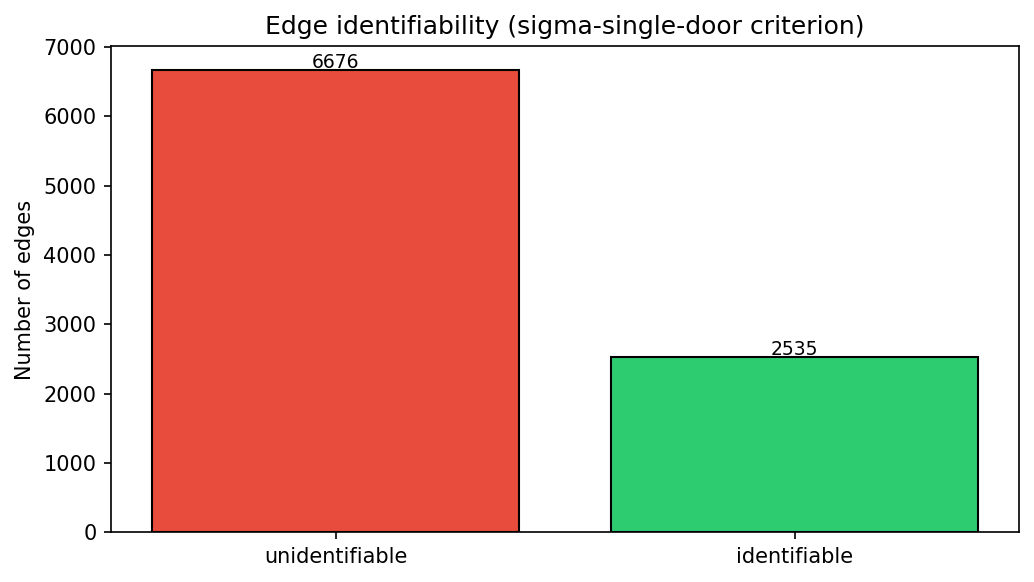

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_identifiability_overall.png


In [13]:
status_counts = df["status"].value_counts()
colors = {"identifiable": "#2ecc71", "unidentifiable": "#e74c3c", "timeout": "#f39c12"}
color_list = [colors.get(s, "#95a5a6") for s in status_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(status_counts.index, status_counts.values, color=color_list, edgecolor="black")
ax.set_ylabel("Number of edges")
ax.set_title("Edge identifiability (sigma-single-door criterion)")
for i, (k, v) in enumerate(status_counts.items()):
    ax.text(i, v + 30, str(v), ha="center", fontsize=9)

plt.tight_layout()
out = VIZ_DIR / "csd_identifiability_overall.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
display(Image(str(out)))
print(f"Saved: {out}")

## 3. Adjustment-set analysis

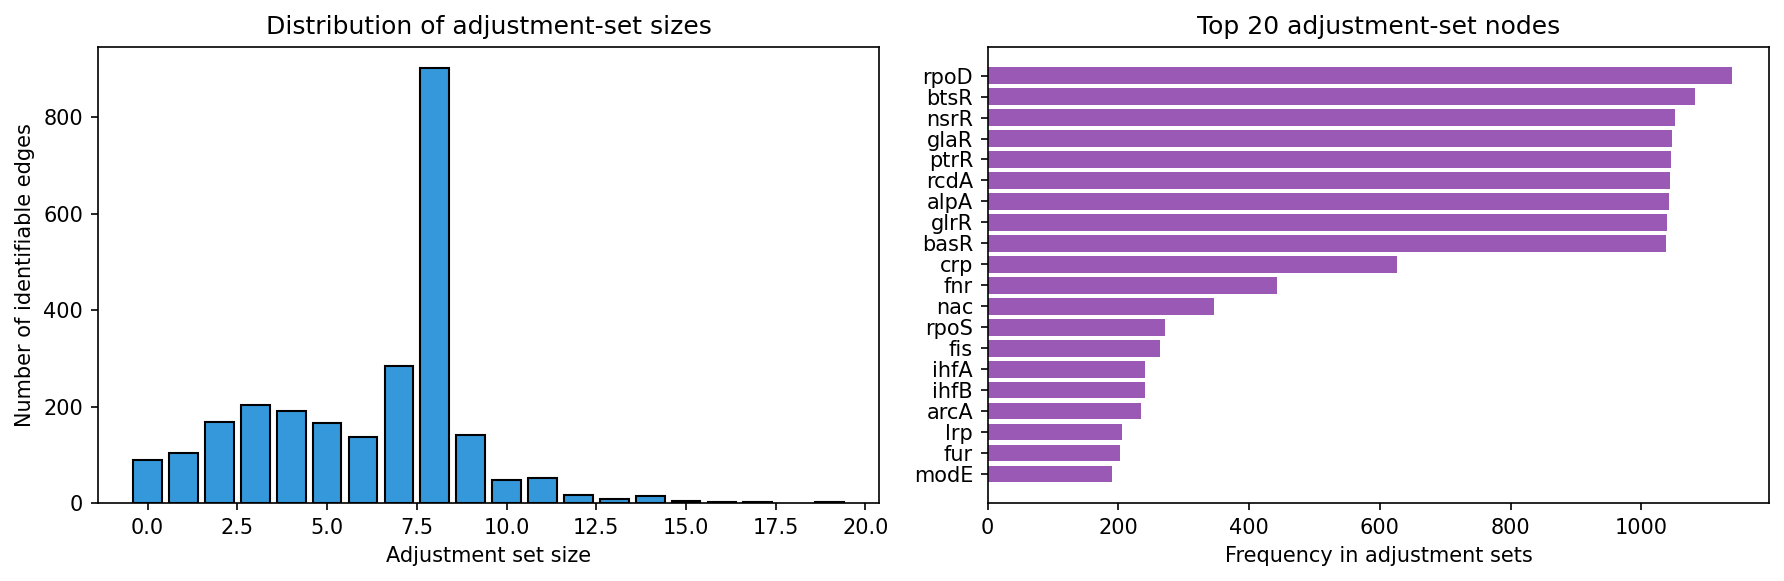

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_adjustment_set_sizes.png

Median adjustment-set size: 7.0
Max adjustment-set size: 19


In [14]:
ident = df[df.status == "identifiable"].copy()
ident["adj_nodes"] = ident["adjustment_set"].fillna("").str.split("|")
ident["adj_size"] = ident["adj_nodes"].apply(lambda x: len(x) if x != [""] else 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Adjustment set size distribution
size_counts = ident["adj_size"].value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color="#3498db", edgecolor="black")
axes[0].set_xlabel("Adjustment set size")
axes[0].set_ylabel("Number of identifiable edges")
axes[0].set_title("Distribution of adjustment-set sizes")

# Top nodes appearing in adjustment sets
all_adj_nodes: list[str] = []
for nodes in ident["adj_nodes"]:
    all_adj_nodes.extend([n for n in nodes if n])
node_counter = Counter(all_adj_nodes)
top_n = 20
top_nodes = node_counter.most_common(top_n)
if top_nodes:
    names, cnts = zip(*top_nodes)
    axes[1].barh(list(names)[::-1], list(cnts)[::-1], color="#9b59b6")
    axes[1].set_xlabel("Frequency in adjustment sets")
    axes[1].set_title(f"Top {top_n} adjustment-set nodes")
else:
    axes[1].text(
        0.5, 0.5, "No adjustment sets", ha="center", va="center", transform=axes[1].transAxes
    )

plt.tight_layout()
out = VIZ_DIR / "csd_adjustment_set_sizes.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
display(Image(str(out)))
print(f"Saved: {out}")
print(f"\nMedian adjustment-set size: {ident['adj_size'].median():.1f}")
print(f"Max adjustment-set size: {ident['adj_size'].max()}")

## 4. Same-SCC vs Cross-SCC identifiability

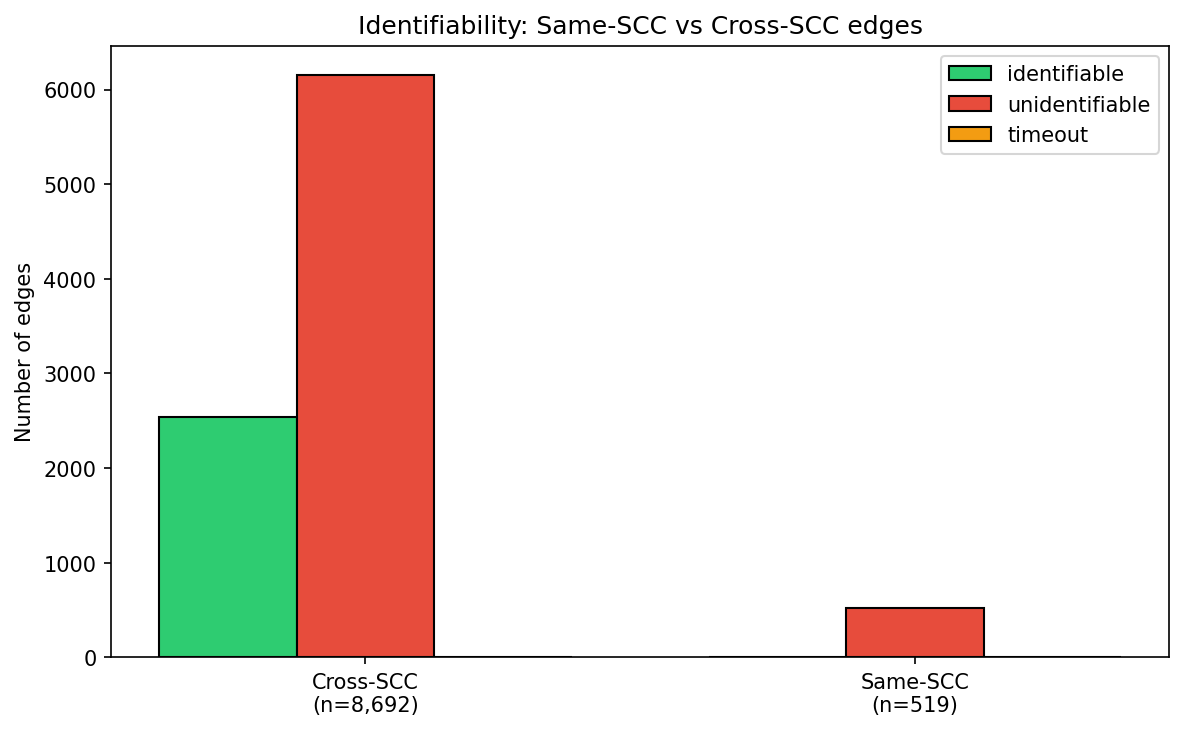

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_same_vs_cross_scc.png

Cross-SCC  identifiable rate: 29.2%
Same-SCC   identifiable rate: 0.0%


In [15]:
cross = df[~df.same_scc]
same = df[df.same_scc]


def rates(sub):
    n = len(sub)
    if n == 0:
        return {"identifiable": 0, "unidentifiable": 0, "timeout": 0, "total": 0}
    return {s: (sub.status == s).sum() for s in ("identifiable", "unidentifiable", "timeout")} | {
        "total": n
    }


r_cross = rates(cross)
r_same = rates(same)

cats = ("identifiable", "unidentifiable", "timeout")
x = [0, 1]
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, cat in enumerate(cats):
    c_vals = [r_cross[cat], r_same[cat]]
    ax.bar(
        [xi + i * width for xi in x],
        c_vals,
        width,
        label=cat,
        color=colors.get(cat, "#95a5a6"),
        edgecolor="black",
    )

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(
    [
        f"Cross-SCC\n(n={r_cross['total']:,})",
        f"Same-SCC\n(n={r_same['total']:,})",
    ]
)
ax.set_ylabel("Number of edges")
ax.set_title("Identifiability: Same-SCC vs Cross-SCC edges")
ax.legend()
plt.tight_layout()
out = VIZ_DIR / "csd_same_vs_cross_scc.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
display(Image(str(out)))
print(f"Saved: {out}")
print(f"\nCross-SCC  identifiable rate: {100 * r_cross['identifiable'] / r_cross['total']:.1f}%")
print(f"Same-SCC   identifiable rate: {100 * r_same['identifiable'] / r_same['total']:.1f}%")

## 5. Non-identifiability cause taxonomy

For each unidentifiable edge we classify the *structural reason*:

| Category | Meaning |
|---|---|
| `self_loop` | cause == effect |
| `two_cycle` | reverse edge effect→cause also exists |
| `same_scc_long` | same SCC even after removing cause→effect (long feedback path) |
| `scc_edge_dissolved` | removing cause→effect breaks the SCC (edge *is* the link) |
| `cross_scc_blocked` | different SCCs but O-set blocked (descendant of effect in O-set) |

Results are pre-computed by `scripts/csd_diagnose_nonident.py` (run once after
gathering the SLURM results) and loaded here for display.

In [16]:
DIAG_CSV = NB_DIR / "csd_nonident_diagnosis.csv"
DIAG_JSON = NB_DIR / "csd_nonident_summary.json"

CAUSE_CATEGORIES = [
    "self_loop",
    "two_cycle",
    "same_scc_long",
    "scc_edge_dissolved",
    "cross_scc_blocked",
]

assert DIAG_CSV.exists(), (
    f"Diagnosis CSV not found: {DIAG_CSV}\nRun:  uv run python scripts/csd_diagnose_nonident.py"
)

unident = pd.read_csv(DIAG_CSV)
cause_counts = unident["nonident_cause"].value_counts()
print(f"Loaded {len(unident):,} unidentifiable edges from {DIAG_CSV.name}")
display(cause_counts.to_frame(name="cause_count"))

Loaded 6,676 unidentifiable edges from csd_nonident_diagnosis.csv


,cause_count
nonident_cause,
cross_scc_blocked,6157
same_scc_long,247
self_loop,174
two_cycle,70
scc_edge_dissolved,28


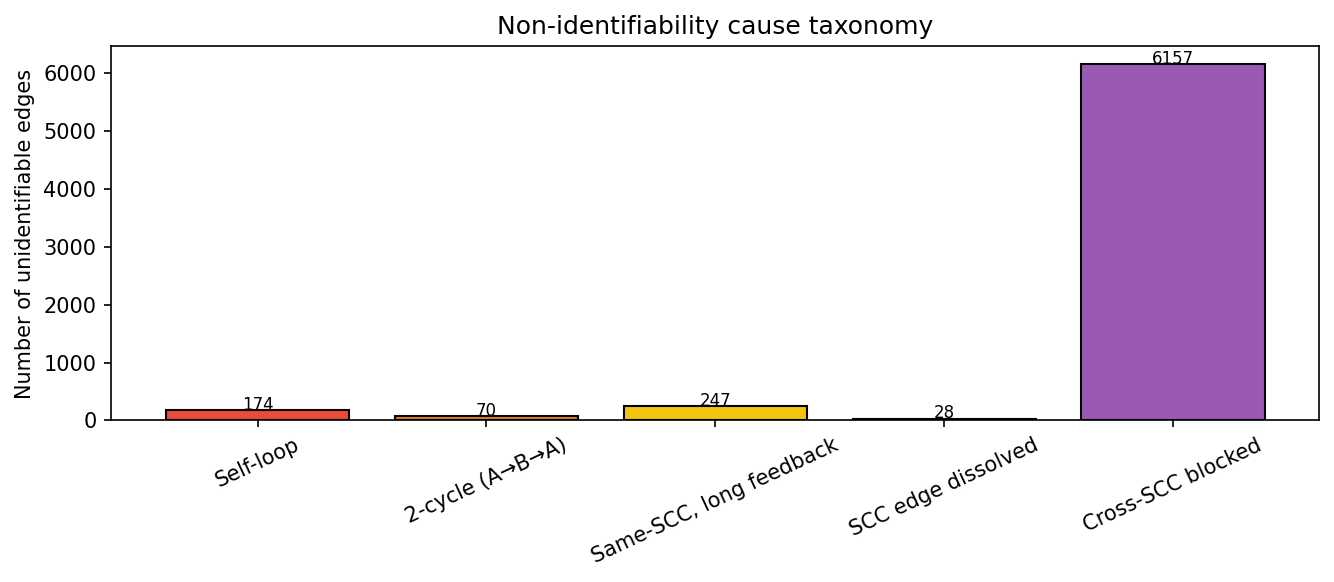

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_nonident_causes.png


In [17]:
CATEGORY_COLORS = {
    "self_loop": "#e74c3c",
    "two_cycle": "#e67e22",
    "same_scc_long": "#f1c40f",
    "scc_edge_dissolved": "#3498db",
    "cross_scc_blocked": "#9b59b6",
    "unknown": "#95a5a6",
}
CATEGORY_LABELS = {
    "self_loop": "Self-loop",
    "two_cycle": "2-cycle (A→B→A)",
    "same_scc_long": "Same-SCC, long feedback",
    "scc_edge_dissolved": "SCC edge dissolved",
    "cross_scc_blocked": "Cross-SCC blocked",
}

ordered = [c for c in CAUSE_CATEGORIES if c in cause_counts.index]
vals = [cause_counts.get(c, 0) for c in ordered]
clrs = [CATEGORY_COLORS.get(c, "#95a5a6") for c in ordered]
labs = [CATEGORY_LABELS.get(c, c) for c in ordered]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labs, vals, color=clrs, edgecolor="black")
ax.set_ylabel("Number of unidentifiable edges")
ax.set_title("Non-identifiability cause taxonomy")
ax.tick_params(axis="x", rotation=25)
for i, v in enumerate(vals):
    ax.text(i, v + 10, str(v), ha="center", fontsize=8)

plt.tight_layout()
out = VIZ_DIR / "csd_nonident_causes.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()
display(Image(str(out)))
print(f"Saved: {out}")

## 6. Intervention rescue results (SLURM)

Each unidentifiable edge is tested to see whether a single hard intervention
`do(v)` on some node `v` would make it identifiable.  This is computationally
expensive (~40–80 s per edge) so the analysis runs on the SLURM cluster via
`scripts/slurm/submit_csd_rescue.sh` and the results are loaded here.

To run the rescue sweep:
```bash
bash scripts/slurm/submit_csd_rescue.sh
# After completion:
uv run python scripts/csd_rescue_gather.py \
    --input-dir results/cyclic_single_door/rescue_classified \
    --output-csv notebooks/Ecoli_Analysis_Notebooks/csd_rescue_results.csv \
    --output-summary notebooks/Ecoli_Analysis_Notebooks/csd_rescue_summary.json
```

In [18]:
RESCUE_CSV = NB_DIR / "csd_rescue_results.csv"
RESCUE_SUMMARY = NB_DIR / "csd_rescue_summary.json"

if not RESCUE_CSV.exists():
    print("Rescue results not yet available.")
    print("Run: bash scripts/slurm/submit_csd_rescue.sh")
else:
    rescue_full = pd.read_csv(RESCUE_CSV)
    with open(RESCUE_SUMMARY) as f:
        rescue_summary = json.load(f)

    print(f"Full sweep: {len(rescue_full):,} unidentifiable edges analysed")
    print(f"Rescuable:  {rescue_summary['n_rescuable']:,} ({rescue_summary['pct_rescuable']}%)")
    print()
    print("Top rescue nodes:")
    for row in rescue_summary["top_rescue_nodes"][:10]:
        print(f"  {row['node']}: {row['count']} edges")

    display(rescue_full.head())

Full sweep: 6,676 unidentifiable edges analysed
Rescuable:  6,400 (95.87%)

Top rescue nodes:
  rpoD: 1862 edges
  crp: 642 edges
  fliZ: 452 edges
  nac: 418 edges
  lrp: 406 edges
  rpoS: 359 edges
  fnr: 336 edges
  fur: 322 edges
  fis: 290 edges
  rpoH: 279 edges


,cause,effect,nonident_cause,rescue_nodes,n_rescue_nodes
0,accA,accA,self_loop,NaN,0
1,accA,accD,two_cycle,accA,1
2,acrR,flhD,same_scc_long,acrR,1
3,flhC,ppdB,cross_scc_blocked,flhC|fliZ,2
4,crp,csgE,cross_scc_blocked,crp,1


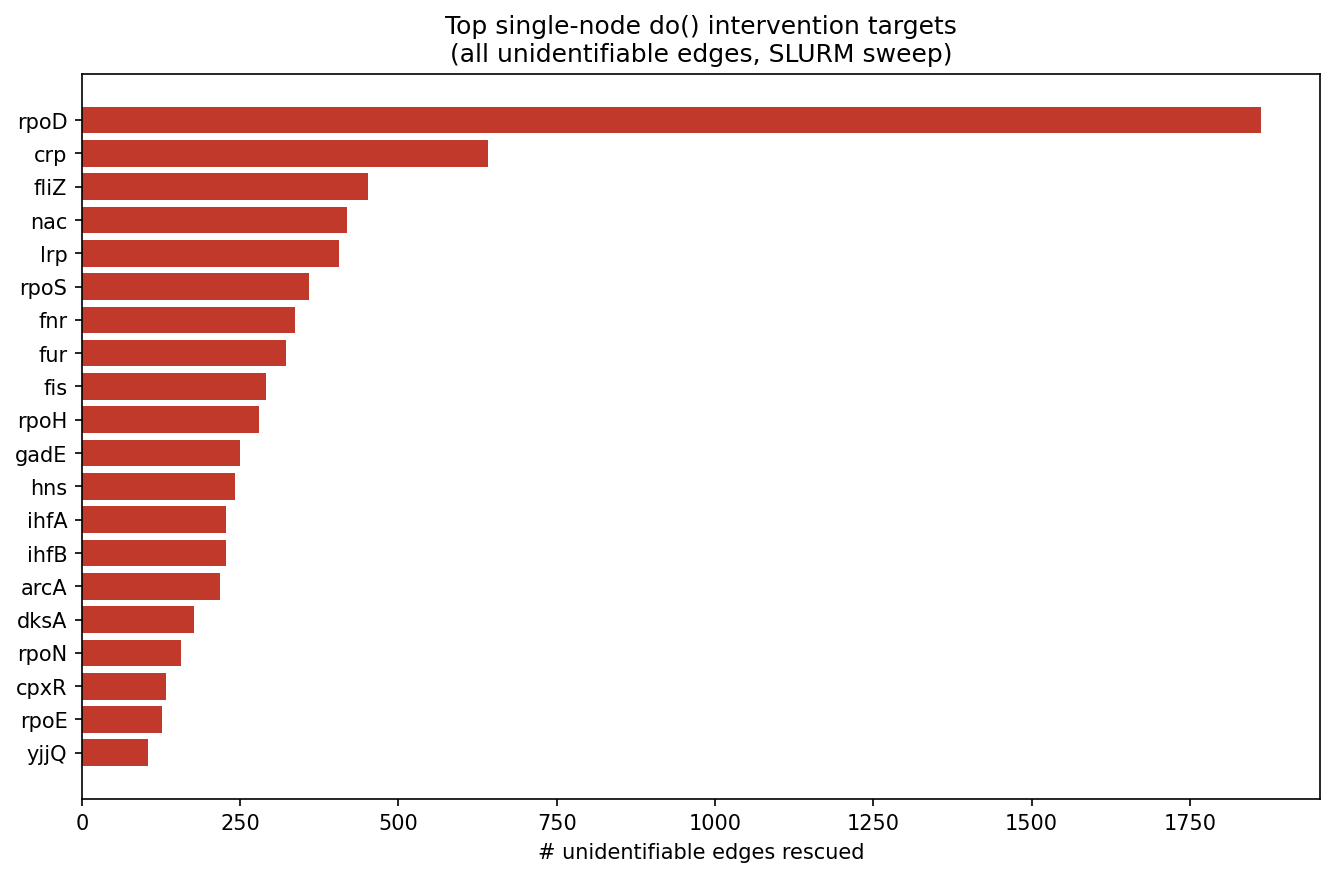

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_rescue_targets_full.png


In [19]:
if RESCUE_CSV.exists():
    top_nodes_full = rescue_summary["top_rescue_nodes"][:20]
    if top_nodes_full:
        names_f, cnts_f = zip(*[(r["node"], r["count"]) for r in top_nodes_full])
        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(list(names_f)[::-1], list(cnts_f)[::-1], color="#c0392b")
        ax.set_xlabel("# unidentifiable edges rescued")
        ax.set_title(
            "Top single-node do() intervention targets\n(all unidentifiable edges, SLURM sweep)"
        )
        plt.tight_layout()
        out = VIZ_DIR / "csd_rescue_targets_full.png"
        plt.savefig(out, dpi=150, bbox_inches="tight")
        plt.close()
        display(Image(str(out)))
        print(f"Saved: {out}")
    else:
        print("No rescue nodes found in sweep.")

## 7. Multi-experiment recovery design

Section 6 shows which single nodes can rescue individual unidentifiable edges.
Here we go one step further: given a budget of **n** multiplex perturbation
experiments each knocking out **k** genes simultaneously, which experiments
should we run to maximise the total number of rescued edges?

`scripts/csd_recovery_bank.py` runs a greedy set-cover optimizer over the
rescue-node lists from the full SLURM sweep and produces two budget designs:

| Design | n experiments | k genes/exp | Edges recovered | % of unidentifiable |
|--------|:---:|:---:|:---:|:---:|
| n=10, k=3 | 10 | 3 | 6,502 | 97.4% |
| n=5,  k=6 | 5  | 6 | 6,502 | 97.4% |

Both designs recover the same 6,502 edges.  The n=5/k=6 design is
**exactly proxy-calibrated** (proxy–exact gap = 0), meaning the cheap
greedy proxy perfectly predicts exact identifiability coverage.

To regenerate these results:
```bash
uv run python scripts/csd_recovery_bank.py \
    --rescue-csv notebooks/Ecoli_Analysis_Notebooks/csd_rescue_results.csv \
    --graphml notebooks/Ecoli_Analysis_Notebooks/ecoli_full_network_no_small_rna.graphml \
    --output-dir notebooks/Ecoli_Analysis_Notebooks \
    --configs "10,3" "5,6"
```

In [20]:
RECOVERY_SUMMARY = NB_DIR / "csd_recovery_summary.json"

if not RECOVERY_SUMMARY.exists():
    print("Recovery-bank results not yet available.")
    print("Run: uv run python scripts/csd_recovery_bank.py ...")
else:
    with open(RECOVERY_SUMMARY) as f:
        rec = json.load(f)

    for design_key, label in [("n10_k3", "n=10, k=3"), ("n5_k6", "n=5, k=6")]:
        d = rec[design_key]
        gap = d["proxy_vs_exact_gap"]
        gap_str = f"{gap:+d}" if gap != 0 else "0 (exact)"
        print(f"=== {label} ===")
        print(
            f"  Edges recovered : {d['n_recovered_exact']:,} / {d['n_total_unidentifiable']:,}"
            f"  ({d['pct_recovered_of_unident']}% of unidentifiable)"
        )
        print(f"  Proxy-exact gap : {gap_str}")
        rows = [
            {"experiment": s["set_index"], "genes": ", ".join(s["genes"]), "k": len(s["genes"])}
            for s in d["chosen_sets"]
        ]
        display(pd.DataFrame(rows).set_index("experiment"))
        print()

=== n=10, k=3 ===
  Edges recovered : 6,502 / 6,676  (97.39% of unidentifiable)
  Proxy-exact gap : -3


,genes,k
experiment,,
1,"gadE, gadX, rpoD",3
2,"fliZ, fur, rpoH",3
3,"fis, nac, rpoE",3
4,"hns, marA, rpoS",3
5,"argR, dksA, fnr",3
6,"accA, bglJ, cra",3
7,"dinJ, exuR, galR",3
8,"gutM, higA, hipA",3
9,"ihfA, mazE, relB",3



=== n=5, k=6 ===
  Edges recovered : 6,502 / 6,676  (97.39% of unidentifiable)
  Proxy-exact gap : 0 (exact)


,genes,k
experiment,,
1,"crp, fliZ, fur, gadE, gadX, rpoD",6
2,"fnr, hns, ihfA, lrp, marA, rpoE",6
3,"accA, bglJ, dinJ, exuR, galR, glnG",6
4,"gutM, higA, hipA, mazE, relB, rhaR",6
5,"accA, accD, nac, rpoS, rpsF, yefM",6


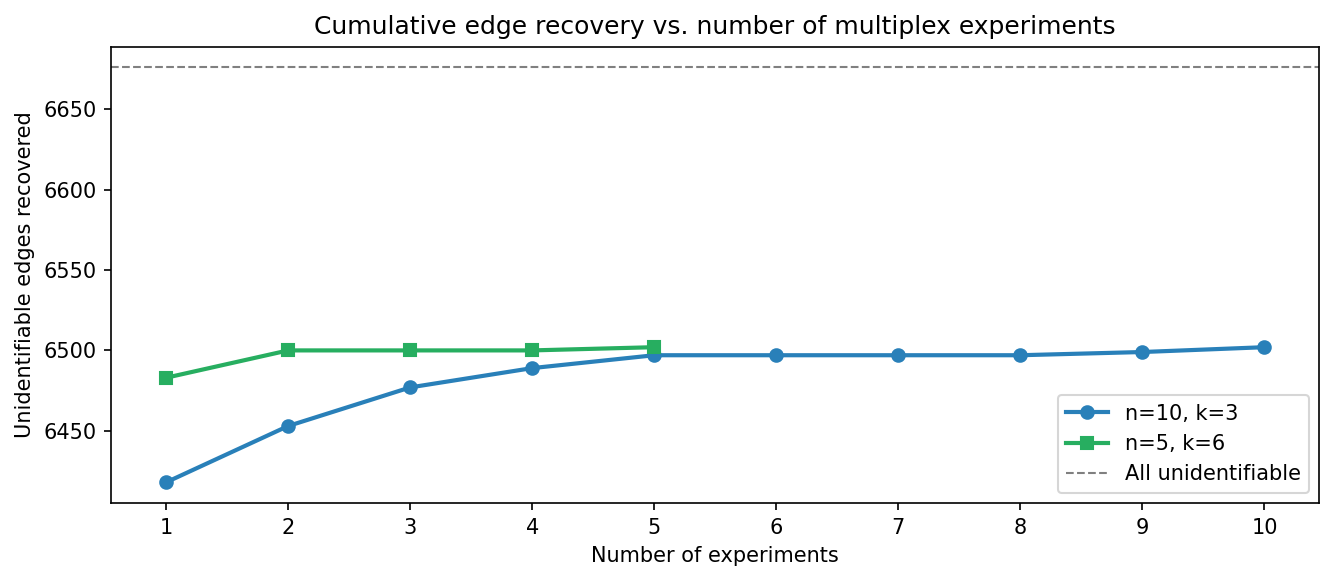

Saved: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/visualizations/csd_recovery_marginal_curve.png


In [21]:
if RECOVERY_SUMMARY.exists():
    fig, ax = plt.subplots(figsize=(9, 4))

    design_styles = {
        "n10_k3": {"label": "n=10, k=3", "color": "#2980b9", "marker": "o"},
        "n5_k6": {"label": "n=5, k=6", "color": "#27ae60", "marker": "s"},
    }

    for design_key, style in design_styles.items():
        d = rec[design_key]
        marginal = d["marginal_curve_exact"]
        cumulative = []
        total = 0
        for v in marginal:
            total += v
            cumulative.append(total)
        x = list(range(1, len(cumulative) + 1))
        ax.plot(
            x,
            cumulative,
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            linewidth=2,
            markersize=6,
        )

    ax.axhline(
        rec["n10_k3"]["n_total_unidentifiable"],
        color="gray",
        linestyle="--",
        linewidth=1,
        label="All unidentifiable",
    )
    ax.set_xlabel("Number of experiments")
    ax.set_ylabel("Unidentifiable edges recovered")
    ax.set_title("Cumulative edge recovery vs. number of multiplex experiments")
    ax.legend()
    ax.set_xticks(
        range(
            1,
            max(
                len(rec["n10_k3"]["marginal_curve_exact"]),
                len(rec["n5_k6"]["marginal_curve_exact"]),
            )
            + 1,
        )
    )
    plt.tight_layout()
    out = VIZ_DIR / "csd_recovery_marginal_curve.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.close()
    display(Image(str(out)))
    print(f"Saved: {out}")

## 8. Export final tables

In [22]:
# Export identifiable edges
ident_out = df[df.status == "identifiable"][["cause", "effect", "adjustment_set", "same_scc"]]
ident_out.to_csv(NB_DIR / "csd_identifiable_edges.csv", index=False)
print(f"Identifiable edges: {len(ident_out):,} -> csd_identifiable_edges.csv")

# Export non-identifiability diagnosis (if computed above)
diag_path = NB_DIR / "csd_nonident_diagnosis.csv"
if diag_path.exists():
    print(f"Non-identifiability diagnosis: {diag_path}")

print("\nAll done.")

Identifiable edges: 2,535 -> csd_identifiable_edges.csv
Non-identifiability diagnosis: /qfs/projects/crispr_carb/Jeremy/nocap/notebooks/Ecoli_Analysis_Notebooks/csd_nonident_diagnosis.csv

All done.
